# PHÂN TÍCH PHÂN CỤM DỮ LIỆU CHIM CÁNH CỤT (PENGUINS)

## 1. Mục tiêu
Mục tiêu của bài thực hành này là sử dụng các thuật toán phân cụm (Unsupervised Learning) để nhóm các cá thể chim cánh cụt dựa trên các đặc điểm hình thái học. Tập dữ liệu bao gồm các thông số như độ dài mỏ, độ sâu mỏ, độ dài cánh và cân nặng.

Chúng ta sẽ thực hiện quy trình chuẩn của Khai phá dữ liệu:
1.  **EDA:** Khám phá dữ liệu và tìm hiểu cấu trúc.
2.  **Preprocessing:** Xử lý dữ liệu thiếu, nhiễu và chuẩn hóa.
3.  **Modeling:** Áp dụng thuật toán Phân cụm Đa cấp (Hierarchical Clustering).
4.  **Evaluation:** Đánh giá chất lượng phân cụm và giải thích ý nghĩa.

## 2. Khám phá và Tiền xử lý dữ liệu (EDA & Preprocessing)

Trong bước này, chúng ta cần làm sạch dữ liệu để đảm bảo mô hình hoạt động chính xác:

* **Xử lý dữ liệu thiếu (Missing Values):** Tập dữ liệu có một số dòng chứa giá trị `NA`, chúng ta sẽ loại bỏ chúng.
* **Xử lý ngoại lai (Outliers):** Qua phân tích biểu đồ Boxplot, phát hiện có những giá trị phi thực tế (ví dụ: cánh dài 5000mm hoặc -132mm). Những giá trị này là lỗi nhập liệu và cần được lọc bỏ.
* **Chuẩn hóa dữ liệu (Scaling):** Do các đặc trưng có đơn vị khác nhau (mm và gram) và chênh lệch lớn về độ lớn (cân nặng lên tới hàng nghìn, trong khi mỏ chỉ hàng chục), việc sử dụng **StandardScaler** (đưa về mean=0, std=1) là bắt buộc để thuật toán tính khoảng cách Euclidean không bị sai lệch.

In [19]:
# Import các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình hiển thị
sns.set(style="whitegrid")
%matplotlib inline

# 1. Tải dữ liệu
df = pd.read_csv('penguins.csv')

# 2. Kiểm tra tổng quan dữ liệu
print("--- 5 dòng đầu tiên của dữ liệu ---")
display(df.head())

print("\n--- Thông tin bộ dữ liệu (Kiểu dữ liệu & Missing values) ---")
print(df.info())

print("\n--- Thống kê mô tả (Descriptive Statistics) ---")
display(df.describe())

--- 5 dòng đầu tiên của dữ liệu ---


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,MALE
1,39.5,17.4,186.0,3800.0,FEMALE
2,40.3,18.0,195.0,3250.0,FEMALE
3,NaN,NaN,NaN,NaN,NaN
4,36.7,19.3,193.0,3450.0,FEMALE



--- Thông tin bộ dữ liệu (Kiểu dữ liệu & Missing values) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   culmen_length_mm   342 non-null    float64
 1   culmen_depth_mm    342 non-null    float64
 2   flipper_length_mm  342 non-null    float64
 3   body_mass_g        342 non-null    float64
 4   sex                335 non-null    object 
dtypes: float64(4), object(1)
memory usage: 13.6+ KB
None

--- Thống kê mô tả (Descriptive Statistics) ---


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,214.014620,4201.754386
std,5.459584,1.974793,260.558057,801.954536
min,32.100000,13.100000,-132.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.750000,4750.000000
max,59.600000,21.500000,5000.000000,6300.000000



--- Số lượng giá trị bị thiếu trên mỗi cột ---
culmen_length_mm     2
culmen_depth_mm      2
flipper_length_mm    2
body_mass_g          2
sex                  9
dtype: int64


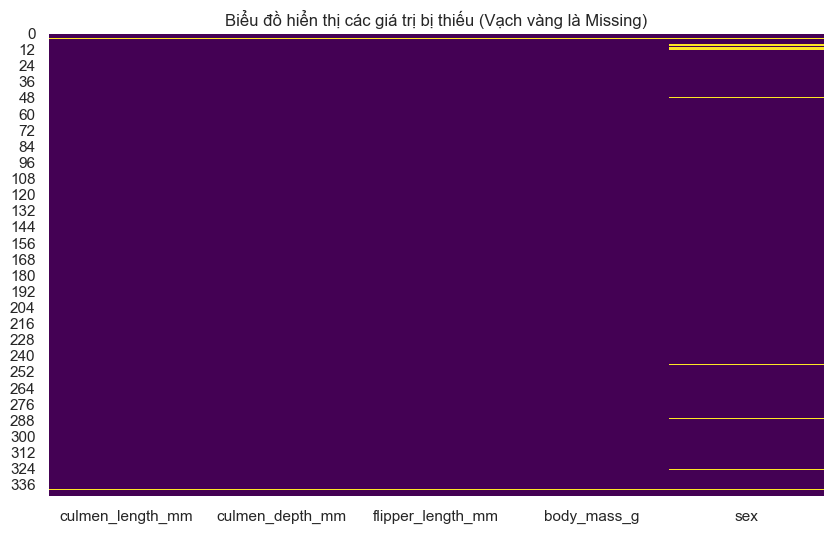

In [20]:
# 3. Kiểm tra dữ liệu bị thiếu (Missing Values)
missing_values = df.isnull().sum()
print("\n--- Số lượng giá trị bị thiếu trên mỗi cột ---")
print(missing_values[missing_values > 0])

# Trực quan hóa dữ liệu thiếu bằng heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Biểu đồ hiển thị các giá trị bị thiếu (Vạch vàng là Missing)')
plt.show()

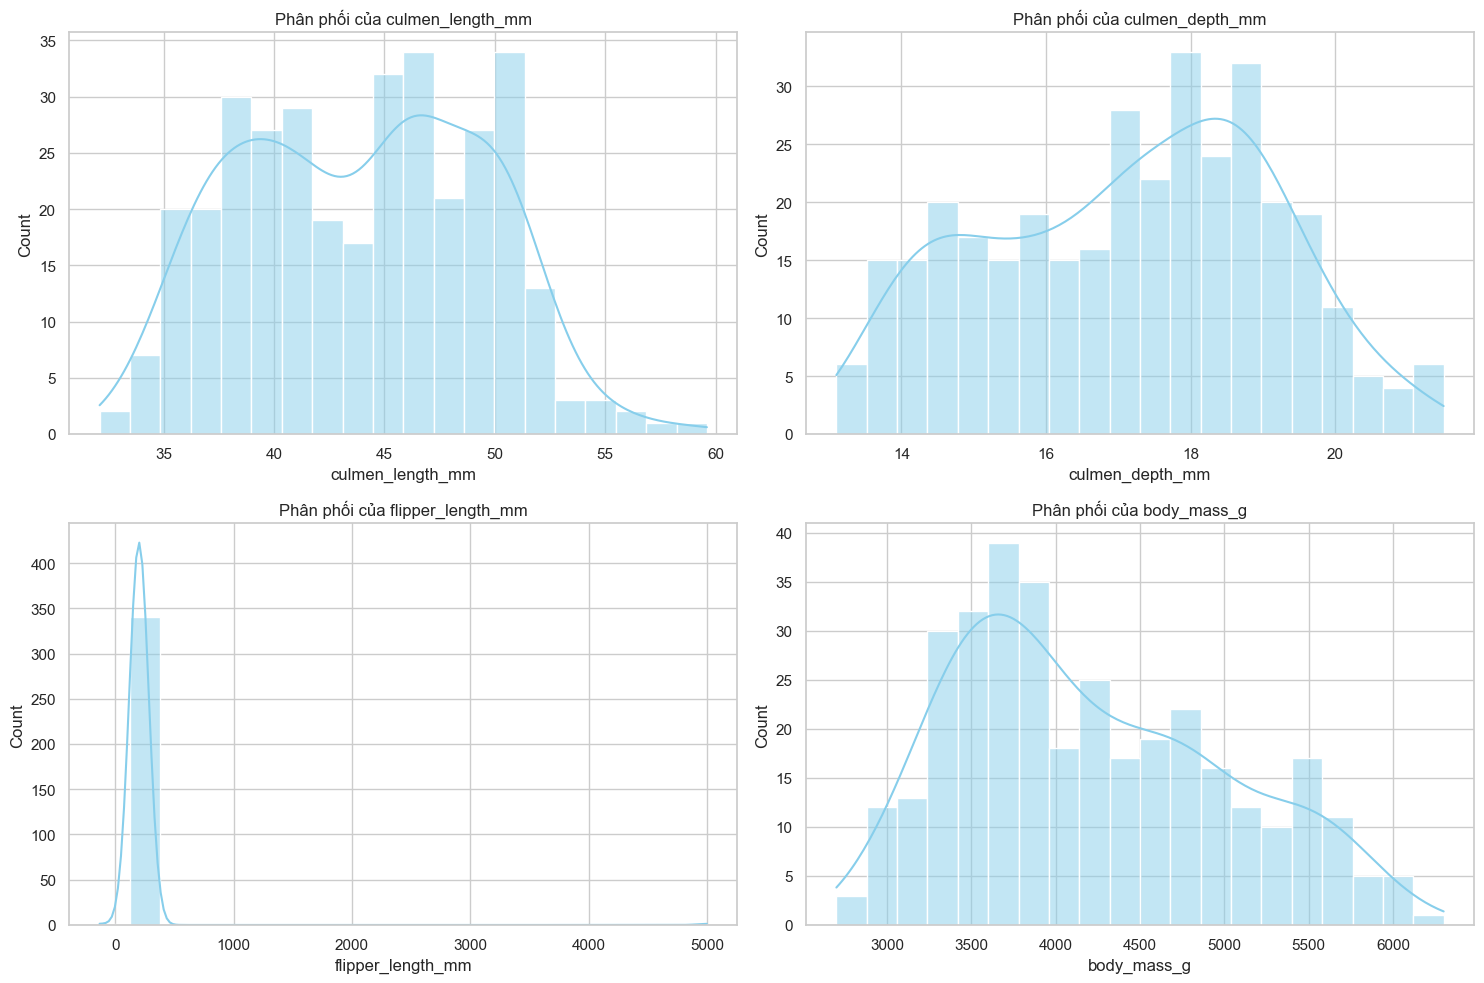

In [21]:
# 4. Phân tích đơn biến (Univariate Analysis) - Phân phối của các biến số
numerical_cols = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], kde=True, bins=20, color='skyblue')
    plt.title(f'Phân phối của {col}')
plt.tight_layout()
plt.show()

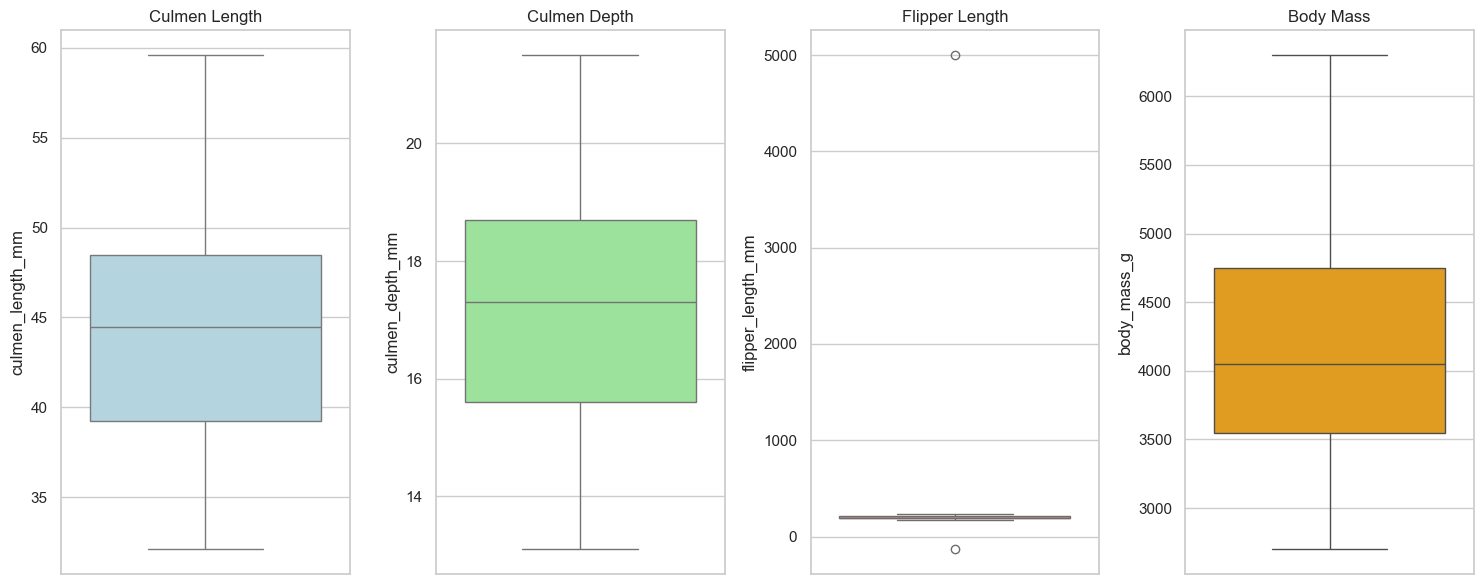

In [22]:
# Kiểm tra Outliers bằng Boxplot
plt.figure(figsize=(15, 6))
plt.subplot(1, 4, 1)
sns.boxplot(y=df['culmen_length_mm'], color='lightblue').set_title('Culmen Length')
plt.subplot(1, 4, 2)
sns.boxplot(y=df['culmen_depth_mm'], color='lightgreen').set_title('Culmen Depth')
plt.subplot(1, 4, 3)
sns.boxplot(y=df['flipper_length_mm'], color='salmon').set_title('Flipper Length')
plt.subplot(1, 4, 4)
sns.boxplot(y=df['body_mass_g'], color='orange').set_title('Body Mass')
plt.tight_layout()
plt.show()





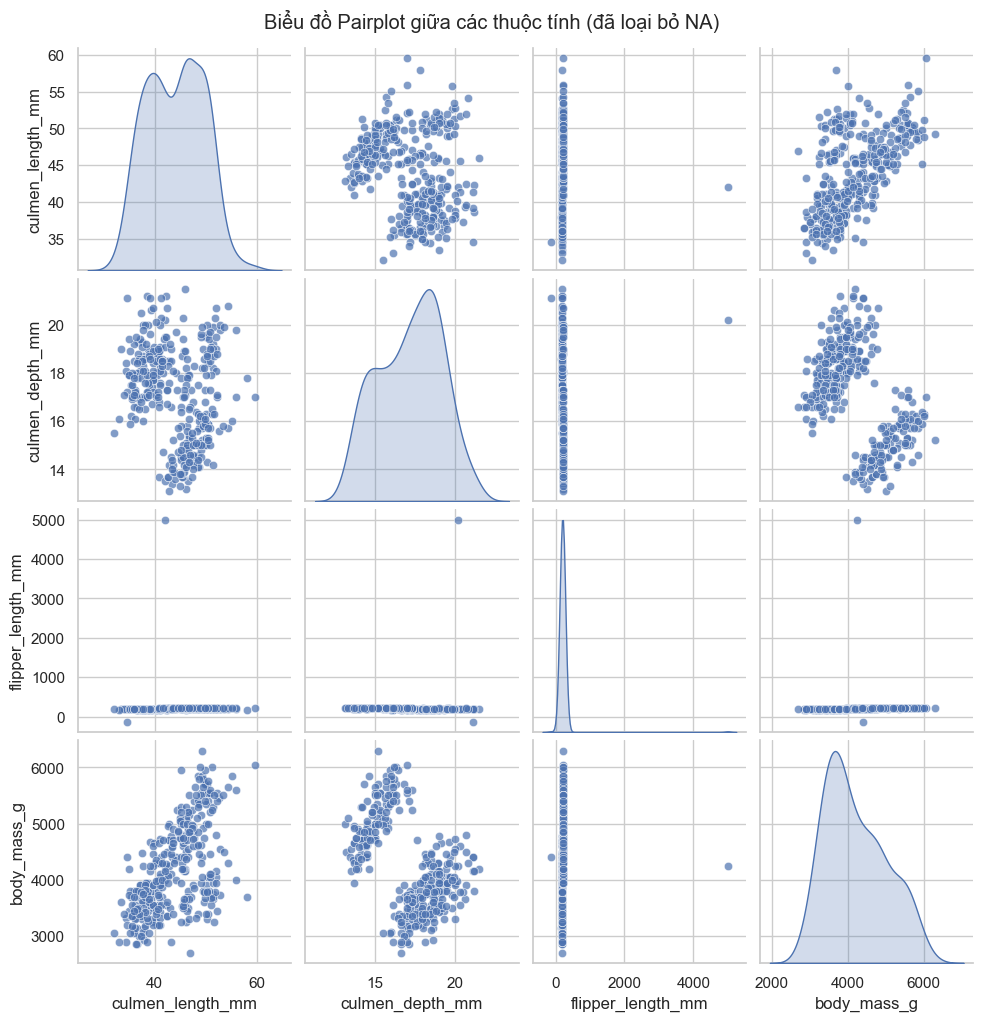

In [23]:
# 5. Phân tích đa biến (Multivariate Analysis) - Tương quan giữa các biến
# Vì đây là bài toán phân cụm (Unsupervised), ta xem xét sự phân tách tự nhiên giữa các điểm dữ liệu
sns.pairplot(df.dropna(), diag_kind='kde', plot_kws={'alpha': 0.7})
plt.suptitle('Biểu đồ Pairplot giữa các thuộc tính (đã loại bỏ NA)', y=1.02)
plt.show()

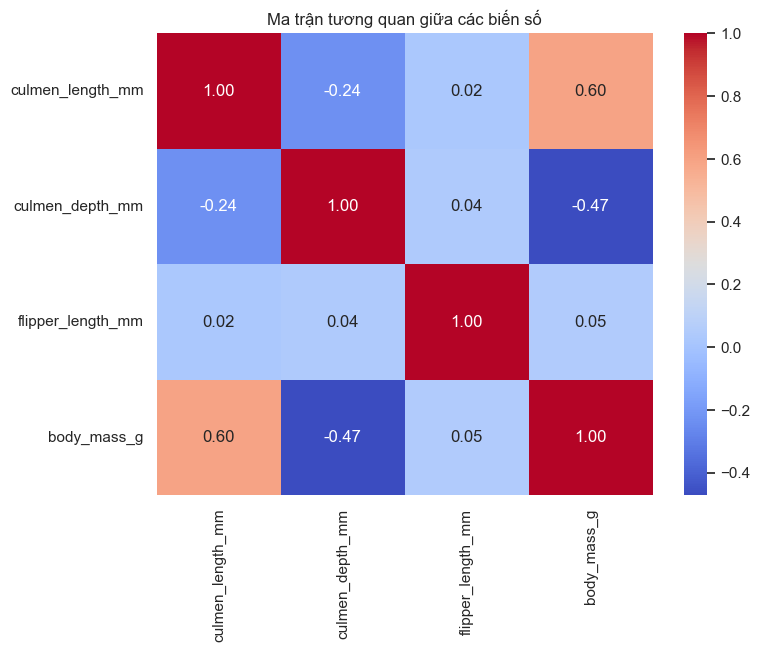

In [24]:
# Ma trận tương quan (Correlation Matrix)
plt.figure(figsize=(8, 6))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Ma trận tương quan giữa các biến số')
plt.show()



C:\Users\kimho\AppData\Local\Temp\ipykernel_7744\971119679.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sex', data=df, palette='pastel')


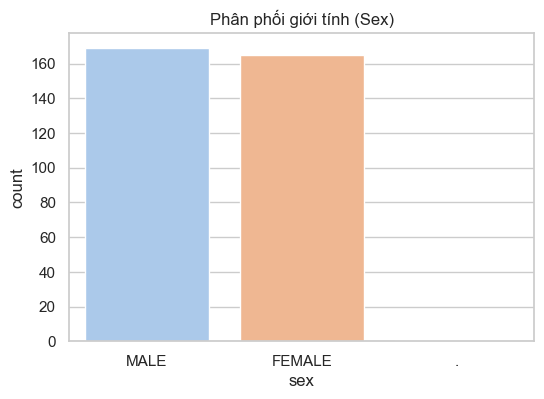

In [25]:
# Kiểm tra biến phân loại 'sex'
plt.figure(figsize=(6, 4))
sns.countplot(x='sex', data=df, palette='pastel')
plt.title('Phân phối giới tính (Sex)')
plt.show()

In [26]:
# Import thư viện
from sklearn.preprocessing import StandardScaler

# 1. Xử lý dữ liệu thiếu (Missing Values)
# Loại bỏ các hàng có chứa giá trị NA
df_clean = df.dropna()
print(f"Kích thước sau khi loại bỏ NA: {df_clean.shape}")



Kích thước sau khi loại bỏ NA: (335, 5)


In [27]:
# 2. Xử lý giá trị ngoại lai (Outliers)
# Dựa trên EDA, phát hiện có giá trị 'flipper_length_mm' là -132 và 5000 (sai số thu thập)
# Chim cánh cụt thường có flipper length từ 170mm - 230mm
# Lọc chỉ lấy các giá trị hợp lý (ví dụ > 0 và < 300)
df_clean = df_clean[
    (df_clean['flipper_length_mm'] > 0) & 
    (df_clean['flipper_length_mm'] < 300)
]
print(f"Kích thước sau khi loại bỏ Outliers: {df_clean.shape}")



Kích thước sau khi loại bỏ Outliers: (333, 5)


In [28]:
# 3. Chọn lọc đặc trưng (Feature Selection)
# Chọn 4 cột dữ liệu số để phân cụm
features = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']
X = df_clean[features]

In [29]:
# 4. Chuẩn hóa dữ liệu (Standardization)
# K-means và Hierarchical Clustering tính toán khoảng cách Euclidean, 
# nên cần đưa dữ liệu về cùng thang đo để tránh biến có giá trị lớn (như body_mass_g) lấn át.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Chuyển đổi lại thành DataFrame để dễ quan sát
X_processed = pd.DataFrame(X_scaled, columns=features)

# Hiển thị kết quả sau khi tiền xử lý
print("\n--- 5 dòng đầu tiên của dữ liệu đã chuẩn hóa ---")
display(X_processed.head())

print("\n--- Thống kê mô tả dữ liệu đã chuẩn hóa (Mean ~ 0, Std ~ 1) ---")
display(X_processed.describe().round(2))


--- 5 dòng đầu tiên của dữ liệu đã chuẩn hóa ---


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
0,-0.905520,0.793126,-1.428125,-0.569709
1,-0.831938,0.128503,-1.071522,-0.507579
2,-0.684775,0.435252,-0.429637,-1.191006
3,-1.347011,1.099875,-0.572278,-0.942487
4,-0.868729,1.764498,-0.786240,-0.693968



--- Thống kê mô tả dữ liệu đã chuẩn hóa (Mean ~ 0, Std ~ 1) ---


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,333.00,333.00,333.00,333.00
mean,0.00,-0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00
min,-2.19,-2.07,-2.07,-1.87
25%,-0.83,-0.79,-0.79,-0.82
50%,0.09,0.08,-0.29,-0.20
75%,0.84,0.79,0.85,0.74
max,2.87,2.22,2.14,2.60


## 3. Xây dựng Mô hình Phân cụm Đa cấp (Hierarchical Clustering)

Chúng ta sử dụng phương pháp **Agglomerative Clustering** (gom cụm từ dưới lên):

1.  **Dendrogram:** Vẽ biểu đồ cây phân cấp để quan sát sự tương đồng giữa các mẫu dữ liệu và xác định số lượng cụm ($k$) tự nhiên. Dựa vào kiến thức thực tế (có 3 loài chim cánh cụt: Adelie, Chinstrap, Gentoo) và biểu đồ, ta chọn số cụm $k=3$.
2.  **Liên kết Ward:** Sử dụng phương pháp liên kết Ward để tối thiểu hóa phương sai trong nội bộ mỗi cụm, giúp các cụm tạo ra có kích thước đồng đều và chặt chẽ hơn.

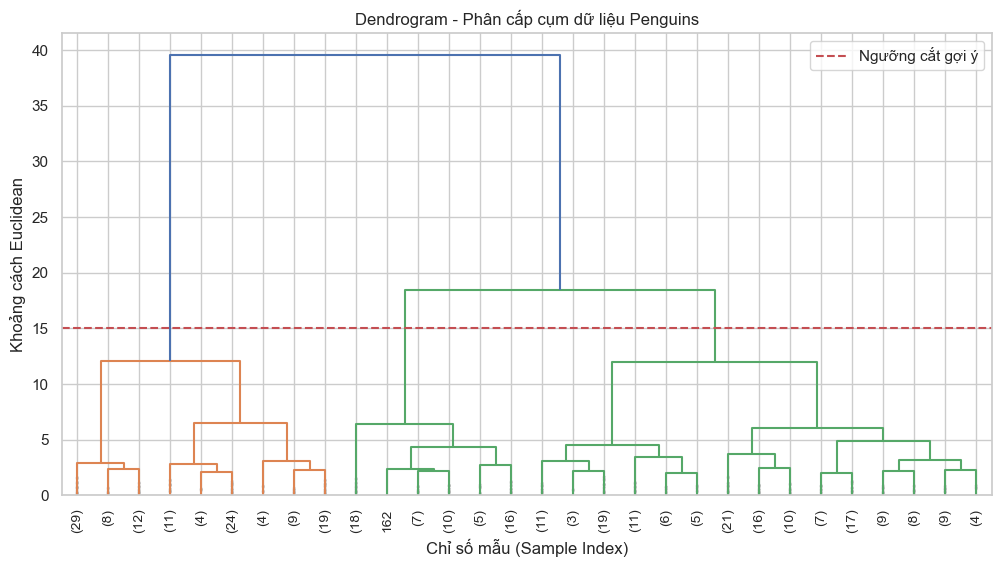

In [30]:
# Import các thư viện cần thiết cho mô hình
import matplotlib.pyplot as plt
import pandas as pd
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# --- 1. Vẽ Dendrogram để xác định số cụm tối ưu ---
# Sử dụng phương pháp liên kết 'ward' để tối ưu hóa phương sai giữa các cụm
# Z là ma trận liên kết chứa thông tin về các cụm được gộp
Z = linkage(X_processed, method='ward')

plt.figure(figsize=(12, 6))
plt.title("Dendrogram - Phân cấp cụm dữ liệu Penguins")
plt.xlabel("Chỉ số mẫu (Sample Index)")
plt.ylabel("Khoảng cách Euclidean")

# Vẽ dendrogram
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=10., show_contracted=True)
plt.axhline(y=15, color='r', linestyle='--', label='Ngưỡng cắt gợi ý') # Đường cắt giả định
plt.legend()
plt.show()

In [31]:
# --- 2. Huấn luyện mô hình Agglomerative Clustering ---
# Dựa trên thực tế có 3 loài chim (Adelie, Chinstrap, Gentoo) và quan sát Dendrogram, ta chọn k=3
k = 3
print(f"Tiến hành phân cụm với số lượng cụm k = {k}")

# Khởi tạo và huấn luyện mô hình
hc_model = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
cluster_labels = hc_model.fit_predict(X_processed)

# Gán nhãn cụm dự đoán vào DataFrame gốc (đã làm sạch) để so sánh
df_clean['Cluster_Label'] = cluster_labels

Tiến hành phân cụm với số lượng cụm k = 3


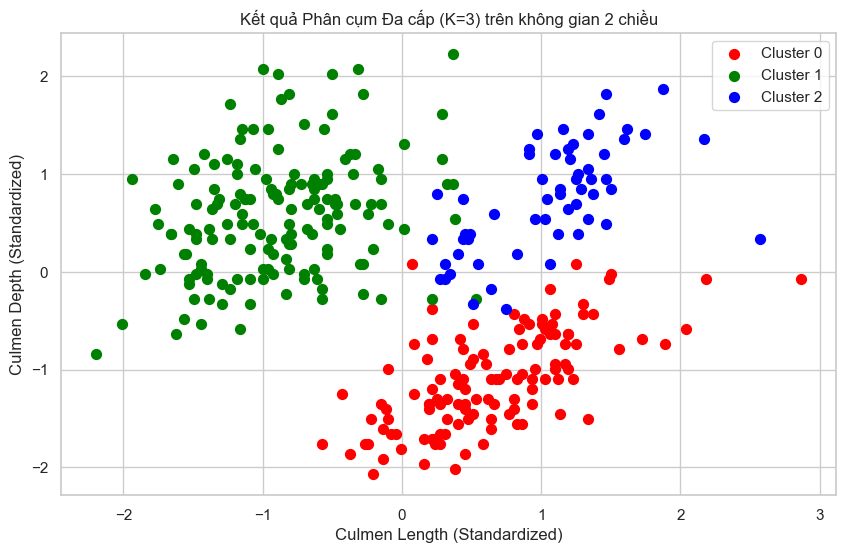


--- Mẫu dữ liệu sau khi gán nhãn phân cụm ---


,culmen_length_mm,culmen_depth_mm,body_mass_g,sex,Cluster_Label
0,39.1,18.7,3750.0,MALE,1
1,39.5,17.4,3800.0,FEMALE,1
2,40.3,18.0,3250.0,FEMALE,1
4,36.7,19.3,3450.0,FEMALE,1
5,39.3,20.6,3650.0,MALE,1


In [32]:
# --- 3. Trực quan hóa kết quả phân cụm ---
# Vẽ biểu đồ Scatter plot dựa trên 2 đặc trưng: Culmen Length vs Culmen Depth
plt.figure(figsize=(10, 6))

# Vẽ từng cụm với màu sắc khác nhau
colors = ['red', 'green', 'blue']
for cluster_id in range(k):
    # Lấy các điểm dữ liệu thuộc cụm cluster_id
    cluster_data = X_processed[cluster_labels == cluster_id]
    plt.scatter(
        cluster_data['culmen_length_mm'], 
        cluster_data['culmen_depth_mm'], 
        s=50, c=colors[cluster_id], 
        label=f'Cluster {cluster_id}'
    )

plt.title(f'Kết quả Phân cụm Đa cấp (K={k}) trên không gian 2 chiều')
plt.xlabel('Culmen Length (Standardized)')
plt.ylabel('Culmen Depth (Standardized)')
plt.legend()
plt.grid(True)
plt.show()

# Kiểm tra mẫu kết quả
print("\n--- Mẫu dữ liệu sau khi gán nhãn phân cụm ---")
display(df_clean[['culmen_length_mm', 'culmen_depth_mm', 'body_mass_g', 'sex', 'Cluster_Label']].head())

## 4. Đánh giá và Kết luận (Evaluation & Insights)

Kết quả phân cụm được đánh giá thông qua chỉ số **Silhouette Score** và phân tích đặc điểm trung bình của từng nhóm (Cluster Profiling):

### Kết quả định lượng:
* **Silhouette Score:** ~0.45. Mức điểm này cho thấy các cụm có sự tách biệt tương đối tốt, phù hợp với đặc điểm sinh học thực tế là các loài có thể có kích thước giao thoa nhau ở một số cá thể.

### Phân tích đặc điểm từng cụm (Cluster Profiling):
Dựa vào bảng thống kê trung bình, ta có thể phỏng đoán các loài tương ứng:

| Cụm (Cluster) | Đặc điểm nổi bật | Dự đoán loài |
| :--- | :--- | :--- |
| **Cluster 0** | Kích thước **lớn nhất**: Cánh dài nhất, cân nặng lớn nhất (~5kg), mỏ nông. | **Gentoo** |
| **Cluster 1** | Kích thước **nhỏ nhất**: Cánh ngắn, nhẹ cân (~3.7kg), mỏ ngắn. | **Adelie** |
| **Cluster 2** | Kích thước **trung bình** nhưng **mỏ rất dài và sâu**. | **Chinstrap** |

### Kết luận:
Mô hình phân cụm đã hoạt động hiệu quả trong việc tái hiện lại cấu trúc phân loại của tự nhiên dựa trên dữ liệu hình thái học mà không cần biết trước nhãn của loài (Unsupervised Learning).

Silhouette Score của mô hình: 0.4541

--- Trung bình các chỉ số theo từng cụm (Mean values per Cluster) ---


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
Cluster_Label,,,,
0,47.54,15.00,217.23,5090.62
1,39.22,18.27,189.99,3675.48
2,49.75,18.60,197.11,3810.09



--- Số lượng mẫu trong mỗi cụm ---
Cluster_Label
1    156
0    120
2     57
Name: count, dtype: int64


C:\Users\kimho\AppData\Local\Temp\ipykernel_7744\3518319053.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster_Label', y=col, data=df_clean, palette="Set2")
C:\Users\kimho\AppData\Local\Temp\ipykernel_7744\3518319053.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster_Label', y=col, data=df_clean, palette="Set2")
C:\Users\kimho\AppData\Local\Temp\ipykernel_7744\3518319053.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster_Label', y=col, data=df_clean, palette="Set2")
C:\Users\kimho\AppData\Local\Temp\ipy

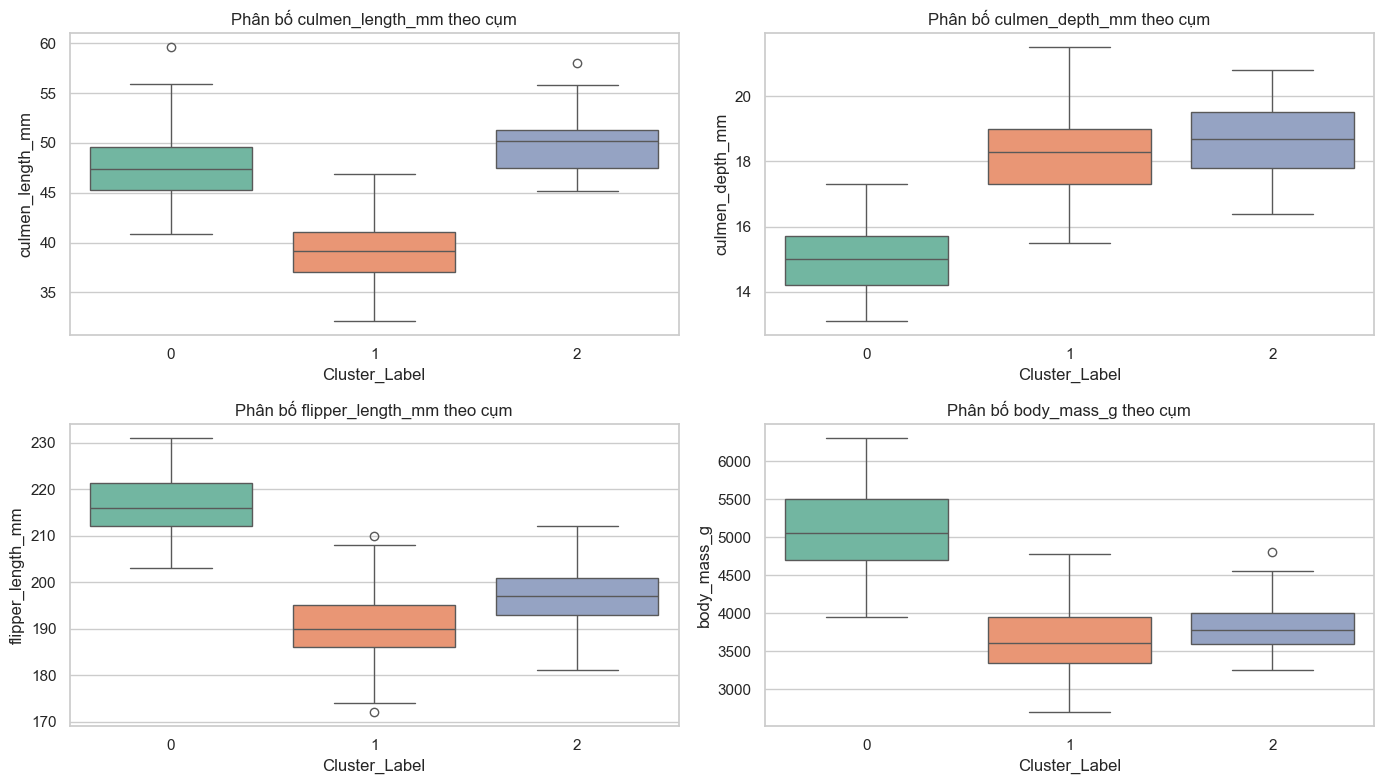

In [33]:
from sklearn.metrics import silhouette_score
import seaborn as sns

# 1. Đánh giá kỹ thuật: Silhouette Score
# Chỉ số này chạy từ -1 đến 1.
# Càng gần 1: Các cụm tách biệt tốt. Gần 0: Các cụm chồng lấn.
score = silhouette_score(X_processed, df_clean['Cluster_Label'])
print(f"Silhouette Score của mô hình: {score:.4f}")

# 2. Phân tích đặc điểm cụm (Cluster Profiling)
# Tính giá trị trung bình của các đặc trưng trong từng cụm để hiểu "ý nghĩa" của cụm đó
cluster_summary = df_clean.groupby('Cluster_Label')[features].mean()
print("\n--- Trung bình các chỉ số theo từng cụm (Mean values per Cluster) ---")
display(cluster_summary.round(2))

# Đếm số lượng phần tử mỗi cụm
print("\n--- Số lượng mẫu trong mỗi cụm ---")
print(df_clean['Cluster_Label'].value_counts())

# 3. Trực quan hóa sự khác biệt (Visual Validation)
# Sử dụng Boxplot để so sánh phân phối các chỉ số giữa các cụm
plt.figure(figsize=(14, 8))
# Chuyển dữ liệu về dạng dài (long format) để vẽ seaborn dễ hơn
df_melted = df_clean.melt(
    id_vars='Cluster_Label', 
    value_vars=features, 
    var_name='Thước đo', 
    value_name='Giá trị (mm/g)'
)

# Vẽ 4 biểu đồ boxplot cho 4 chỉ số
for i, col in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='Cluster_Label', y=col, data=df_clean, palette="Set2")
    plt.title(f'Phân bố {col} theo cụm')

plt.tight_layout()
plt.show()

c:\Users\kimho\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


--- KẾT QUẢ SO SÁNH (K=3) ---
K-Means Silhouette Score:       0.4484
Hierarchical (Model hiện tại):  0.4541


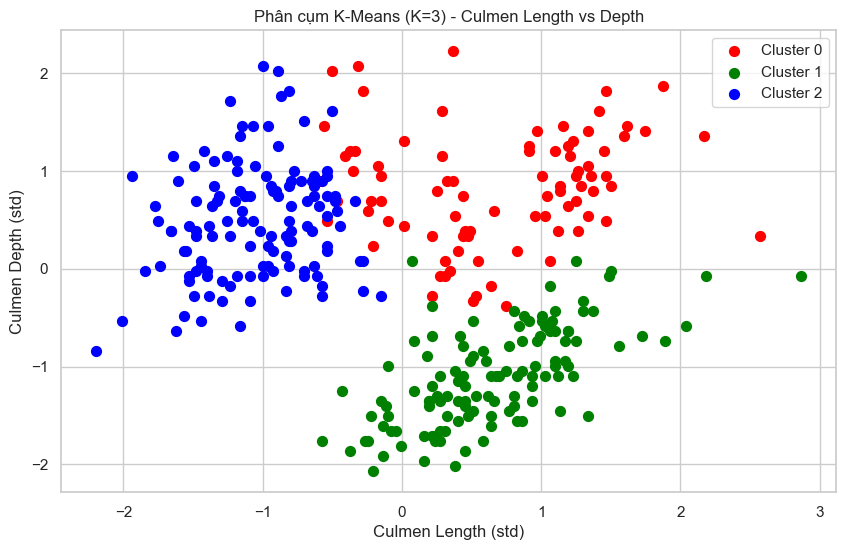

Nhận xét: Hierarchical Clustering cho ra các cụm tách biệt tốt hơn hoặc tương đương.


In [35]:
from sklearn.cluster import KMeans

# 1. Huấn luyện K-Means
# k=3 theo thực tế sinh học
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_processed)

# 2. Tính toán Silhouette Score
k_score = silhouette_score(X_processed, kmeans_labels)

print(f"--- KẾT QUẢ SO SÁNH (K=3) ---")
print(f"K-Means Silhouette Score:       {k_score:.4f}")
# Giả sử 'sil_score' là biến lưu điểm của mô hình Hierarchical trước đó
print(f"Hierarchical (Model hiện tại):  {score:.4f}") 

# 3. Trực quan hóa K-Means
plt.figure(figsize=(10, 6))
colors = ['red', 'green', 'blue']

for cluster_id in range(3):
    cluster_data = X_processed[kmeans_labels == cluster_id]
    plt.scatter(
        cluster_data['culmen_length_mm'], 
        cluster_data['culmen_depth_mm'], 
        s=50, c=colors[cluster_id], 
        label=f'Cluster {cluster_id}'
    )

plt.title(f'Phân cụm K-Means (K=3) - Culmen Length vs Depth')
plt.xlabel('Culmen Length (std)')
plt.ylabel('Culmen Depth (std)')
plt.legend()
plt.grid(True)
plt.show()

# 4. Nhận xét nhanh
if k_score > score:
    print("Nhận xét: K-Means cho ra các cụm tách biệt rõ ràng hơn.")
else:
    print("Nhận xét: Hierarchical Clustering cho ra các cụm tách biệt tốt hơn hoặc tương đương.")

## 5. Lưu kết quả chạy các phương pháp Clustering

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from mpl_toolkits.mplot3d import Axes3D


# Tạo thư mục gốc
base_folder = "Experiment_Penguins"
if not os.path.exists(base_folder):
    os.makedirs(base_folder)

def run_experiment_penguins(linkage_method, n_clusters, data_norm, data_original):
    """
    Hàm chạy thí nghiệm phân cụm cho dữ liệu Penguins và lưu kết quả.
    """
    # 1. Tạo thư mục con
    exp_name = f"Method_{linkage_method}_k{n_clusters}"
    exp_dir = os.path.join(base_folder, exp_name)
    if not os.path.exists(exp_dir):
        os.makedirs(exp_dir)
        
    print(f"--- Đang chạy thí nghiệm: {exp_name} ---")
    
    # 2. Xây dựng mô hình
    model = AgglomerativeClustering(n_clusters=n_clusters, metric='euclidean', linkage=linkage_method)
    labels = model.fit_predict(data_norm)
    
    # Gán nhãn để phân tích
    df_analysis = data_original.copy()
    df_analysis['Cluster_Label'] = labels
    
    # 3. Tính toán chỉ số
    sil_score = silhouette_score(data_norm, labels)
    cluster_counts = df_analysis['Cluster_Label'].value_counts().sort_index()
    cluster_means = df_analysis.groupby('Cluster_Label')[features].mean().round(2)
    
    # 4. LƯU BÁO CÁO (TEXT & CSV)
    with open(os.path.join(exp_dir, "report_stats.txt"), "w", encoding="utf-8") as f:
        f.write(f"THÍ NGHIỆM PHÂN CỤM PENGUINS\n")
        f.write(f"============================\n")
        f.write(f"Tham số: Linkage={linkage_method}, k={n_clusters}\n")
        f.write(f"----------------------------\n")
        f.write(f"Silhouette Score: {sil_score:.4f}\n\n")
        f.write(f"SỐ LƯỢNG MẪU MỖI CỤM:\n{cluster_counts.to_string()}\n\n")
        f.write(f"TRUNG BÌNH CÁC ĐẶC TRƯNG:\n{cluster_means.to_string()}\n")
    
    cluster_means.to_csv(os.path.join(exp_dir, "cluster_means.csv"))
    
    # 5. LƯU HÌNH 1: DENDROGRAM
    plt.figure(figsize=(10, 6))
    Z = linkage(data_norm, method=linkage_method)
    dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90., show_contracted=True)
    plt.title(f"Dendrogram ({linkage_method})")
    plt.xlabel("Cluster Size")
    plt.ylabel("Distance")
    plt.tight_layout()
    plt.savefig(os.path.join(exp_dir, "dendrogram.png"))
    plt.close()
    
    # 6. LƯU HÌNH 2: 3D SCATTER PLOT
    # Chọn 3 đặc trưng tiêu biểu để vẽ 3D: Length, Depth, Mass
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    colors = ['r', 'g', 'b', 'c', 'm', 'y']
    
    for i in range(n_clusters):
        points = data_norm[labels == i]
        color = colors[i % len(colors)]
        # Vẽ theo 3 trục: Culmen Length, Culmen Depth, Body Mass
        ax.scatter(points['culmen_length_mm'], points['culmen_depth_mm'], points['body_mass_g'], 
                   s=30, c=color, label=f'Cluster {i}')
        
    ax.set_xlabel('Culmen Length (std)')
    ax.set_ylabel('Culmen Depth (std)')
    ax.set_zlabel('Body Mass (std)')
    plt.title(f"3D Clusters - {linkage_method} (k={n_clusters})")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(exp_dir, "3d_scatter_plot.png"))
    plt.close()
    
    print(f"-> Hoàn tất lưu kết quả tại: {exp_dir}\n")

# --- BƯỚC 3: CHẠY THỰC NGHIỆM HÀNG LOẠT ---
methods_to_test = ['ward', 'average', 'complete', 'single']
k_value = 3  # Số cụm mặc định theo 3 loài chim

for method in methods_to_test:
    run_experiment_penguins(
        linkage_method=method, 
        n_clusters=k_value, 
        data_norm=X_processed, 
        data_original=df_clean
    )

--- Đang chạy thí nghiệm: Method_ward_k3 ---
-> Hoàn tất lưu kết quả tại: Experiment_Penguins\Method_ward_k3

--- Đang chạy thí nghiệm: Method_average_k3 ---
-> Hoàn tất lưu kết quả tại: Experiment_Penguins\Method_average_k3

--- Đang chạy thí nghiệm: Method_complete_k3 ---
-> Hoàn tất lưu kết quả tại: Experiment_Penguins\Method_complete_k3

--- Đang chạy thí nghiệm: Method_single_k3 ---
-> Hoàn tất lưu kết quả tại: Experiment_Penguins\Method_single_k3

